<a href="https://colab.research.google.com/github/HowardChen0211/gisPy/blob/main/ProblemSets_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProblemSet 0



## Research Question:

- How do the dimensions of livability — affordability, economic security, public safety, health, and environmental quality — vary across
California's 58 counties


## Unit of Analysis
Counties in California (n = 58)

#### Install the package (If needed)

In [218]:
# !pip install geopandas
# !pip install mapclassify

#### Import the package from library

In [219]:
import os, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd # gis/maps

import mapclassify # need for thematic map classification

# will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'last_expr' # 'last_expr'

#### Load the dataset
These datasets contain shapefile boundaries for CA State, counties and places from the US Census Bureau's 2023 MAF/TIGER database

In [220]:
# The CA Boundaries data can be found at here https://catalog.data.gov/dataset/ca-geographic-boundaries

# -q = quiet; -O = output filename; saves file as CA_Counties_Boundaries.zip

# CA Counties Boundary dataset
! wget -q -O CA_Counties_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/b0007416-a325-4777-9295-368ea6b710e6/download/ca_counties.zip

# CA State Boundary dataset
! wget -q -O CA_State_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/3db1e426-fb51-44f5-82d5-a54d7c6e188b/download/ca_state.zip

# CA Places Boundary dataset
! wget -q -O CA_Places_Boundaries.zip https://data.ca.gov/dataset/e212e397-1277-4df3-8c22-40721b095f33/resource/436fc714-831c-4070-b44b-b06dcde6bf18/download/ca_places.zip

In [221]:
# Unzip the file
# zip_ref = zipfile.ZipFile('CA_Counties_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
# zip_ref = zipfile.ZipFile('CA_State_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()
# zip_ref = zipfile.ZipFile('CA_Places_Boundaries.zip', 'r'); zip_ref.extractall(); zip_ref.close()

In [222]:
for z in ["CA_Counties_Boundaries.zip", "CA_State_Boundaries.zip", "CA_Places_Boundaries.zip"]:
  with zipfile.ZipFile(z, 'r') as zf:
    zf.extractall()

!ls # see what we got

CA_Counties_Boundaries.zip  CA_Places.cpg	     CA_State.dbf
CA_Counties.cpg		    CA_Places.dbf	     CA_State.prj
CA_Counties.dbf		    CA_Places.prj	     CA_State.sbn
CA_Counties.prj		    CA_Places.sbn	     CA_State.sbx
CA_Counties.sbn		    CA_Places.sbx	     CA_State.shp
CA_Counties.sbx		    CA_Places.shp	     CA_State.shp.xml
CA_Counties.shp		    CA_Places.shp.xml	     CA_State.shx
CA_Counties.shp.xml	    CA_Places.shx	     sample_data
CA_Counties.shx		    CA_State_Boundaries.zip
CA_Places_Boundaries.zip    CA_State.cpg


### State Boundary

In [223]:
state = gpd.read_file('CA_State.shp') # load the shapefile with gpd as ca_state
state.head() # see the first 5 rows

,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,56,4,9,06,01779778,06,CA,California,00,G4000,A,4.034672e+11,2.049980e+10,+37.1551773,-119.5434183,5.258041e+06,5.258041e+06,6.718927e+11,"MULTIPOLYGON (((-13060108.516 3854208.959, -13..."


In [224]:
state.dtypes # see the data types

,0
OBJECTID,int64
REGION,object
DIVISION,object
STATEFP,object
STATENS,object
GEOID,object
STUSPS,object
NAME,object
LSAD,object
MTFCC,object


In [225]:
state.shape # see the size of the data (1 rows, 19 columns)

(1, 19)

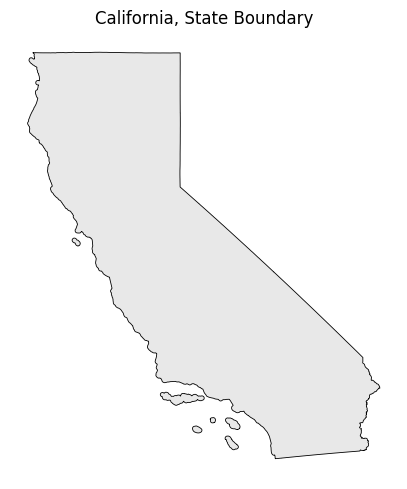

In [226]:
fig, ax = plt.subplots(figsize=(5, 6))
state.plot(ax=ax, color="#e8e8e8", edgecolor="black", linewidth=0.6)
ax.set_title("California, State Boundary")
ax.set_axis_off()
plt.show()

As you can see, it shows the state of California

### Counties Boundary




In [227]:
ca_counties = gpd.read_file('CA_Counties.shp') # load the shapefile with gpd as ca_counties

In [228]:
ca_counties.head() # see the first 5 rows

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry
0,06,091,00277310,06091,Sierra,Sierra County,06,H1,G4020,None,None,None,A,2.468695e+09,2.329911e+07,+39.5769252,-120.5219926,375602.758281,4.200450e+09,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,06,067,00277298,06067,Sacramento,Sacramento County,06,H1,G4020,472,40900,None,A,2.499984e+09,7.542543e+07,+38.4500161,-121.3404408,406584.174167,4.205516e+09,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,06,083,00277306,06083,Santa Barbara,Santa Barbara County,06,H1,G4020,None,42200,None,A,7.084063e+09,2.729752e+09,+34.5370572,-120.0399729,891686.747247,1.449841e+10,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,06,009,01675885,06009,Calaveras,Calaveras County,06,H1,G4020,None,None,None,A,2.641785e+09,4.384187e+07,+38.1838996,-120.5614415,367005.879680,4.356213e+09,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,06,111,00277320,06111,Ventura,Ventura County,06,H1,G4020,348,37100,None,A,4.771988e+09,9.473454e+08,+34.3587415,-119.1331432,527772.242190,8.413293e+09,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


In [229]:
ca_counties.dtypes # see the data types

,0
STATEFP,object
COUNTYFP,object
COUNTYNS,object
GEOID,object
NAME,object
NAMELSAD,object
LSAD,object
CLASSFP,object
MTFCC,object
CSAFP,object


In [230]:
# Check how many features (20)
ca_counties.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')

In [231]:
# Select the column I need
cols = ["GEOID", "NAME", "NAMELSAD", "ALAND", "AWATER", "geometry"]
counties = ca_counties[cols].copy() # don't alter the original data

# Convert the GEOID dtypes
counties["GEOID"] = counties["GEOID"].astype(int)

print("Dimensions:", counties.shape)
counties.head()

Dimensions: (58, 6)


,GEOID,NAME,NAMELSAD,ALAND,AWATER,geometry
0,6091,Sierra,Sierra County,2.468695e+09,2.329911e+07,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,6067,Sacramento,Sacramento County,2.499984e+09,7.542543e+07,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,6083,Santa Barbara,Santa Barbara County,7.084063e+09,2.729752e+09,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,6009,Calaveras,Calaveras County,2.641785e+09,4.384187e+07,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,6111,Ventura,Ventura County,4.771988e+09,9.473454e+08,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


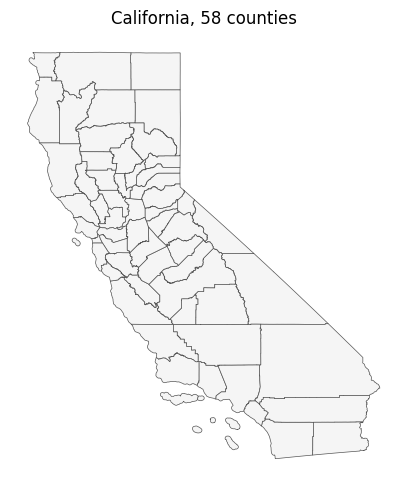

In [232]:
fig, ax = plt.subplots(figsize=(5, 6))
counties.plot(ax=ax, color="#f5f5f5", edgecolor="#555555", linewidth=0.5)
ax.set_title("California, 58 counties")
ax.set_axis_off()
plt.show()

As you can see, it shows 58 counties boundary of California

### Cities Boundary

In [233]:
ca_places = gpd.read_file('CA_Places.shp') # load the shapefile with gpd as ca_places

ca_places.shape # see the size of the data (1521 rows, 19 columns)

(1521, 19)

In [234]:
ca_places.dtypes # see the data types

,0
STATEFP,object
PLACEFP,object
PLACENS,object
GEOID,object
NAME,object
NAMELSAD,object
LSAD,object
CLASSFP,object
PCICBSA,object
PCINECTA,object


In [235]:
ca_places[["NAME", "NAMELSAD", "CLASSFP", "FUNCSTAT"]].head()

,NAME,NAMELSAD,CLASSFP,FUNCSTAT
0,San Fernando,San Fernando city,C1,A
1,Cloverdale,Cloverdale city,C1,A
2,Cotati,Cotati city,C1,A
3,San Buenaventura (Ventura),San Buenaventura (Ventura) city,C1,A
4,Glendora,Glendora city,C1,A


In [236]:
# Using mask method to filter the cities that is incorporated city
mask = (ca_places["CLASSFP"].str.startswith("C", na = False)
        & (ca_places["FUNCSTAT"] == "A"))

cols = ["GEOID", "NAME", "NAMELSAD", "CLASSFP", "ALAND", "AWATER", "geometry"]
cities = ca_places.loc[mask, cols].copy()

print("Dimensions:", cities.shape) # Reduced from 1,521 to 482 incorporated cities

# Convert the GEOID dtypes
cities["GEOID"] = cities["GEOID"].astype(int)

cities.head()

Dimensions: (482, 7)


,GEOID,NAME,NAMELSAD,CLASSFP,ALAND,AWATER,geometry
0,666140,San Fernando,San Fernando city,C1,6148696.0,0.0,"POLYGON ((-13186463.855 4067122.651, -13186256..."
1,614190,Cloverdale,Cloverdale city,C1,8107251.0,0.0,"POLYGON ((-13696207.846 4691208.338, -13696205..."
2,616560,Cotati,Cotati city,C1,4869301.0,8380.0,"POLYGON ((-13662197.838 4626644.613, -13662188..."
3,665042,San Buenaventura (Ventura),San Buenaventura (Ventura) city,C1,56675175.0,26959120.0,"MULTIPOLYGON (((-13280094.138 4075172.878, -13..."
4,630014,Glendora,Glendora city,C1,50527933.0,400123.0,"POLYGON ((-13123461.909 4048524.147, -13123461..."


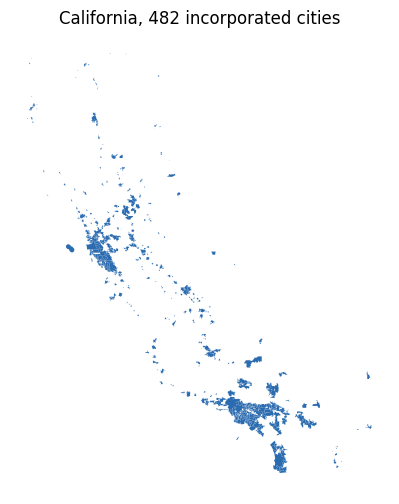

In [237]:
fig, ax = plt.subplots(figsize=(5, 6))
cities.plot(ax=ax, color="#2b6cb0", linewidth=0)
ax.set_title("California, 482 incorporated cities")
ax.set_axis_off()
plt.show()

As you can see, it shows the places of Californiac excluding the Census Designated Places.
And there are three dense clusters(the Bay Area, the Los Angeles basin, and the San Diego coast)

# ProblemSet 1

### Layered Map - Combine Counties, Cities

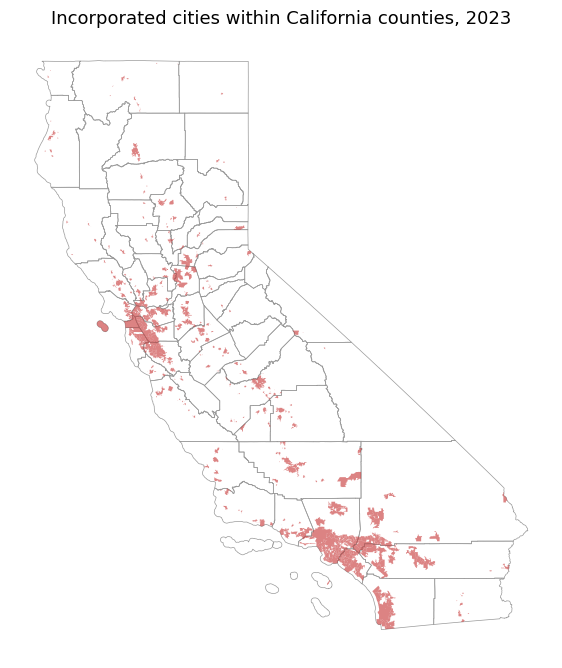

In [238]:
fig, ax = plt.subplots(figsize=(7, 9))

counties.plot(ax=ax, color="none", edgecolor="#999999", linewidth=0.5)
cities.plot(ax=ax, color="#c53030", linewidth=0, alpha=0.6)

ax.set_title("Incorporated cities within California counties, 2023", fontsize=13)
ax.set_axis_off()
plt.show()

## ACS(American Community Survey) Data

Soure: https://www.socialexplorer.com/data-library/2 2020--2024 (5-Year-Estimates)

#### Load the data



In [239]:
# Total population at County level
total_pop = pd.read_csv("https://raw.githubusercontent.com/HowardChen0211/gisPy/refs/heads/main/Population_2024.csv", skiprows=[1])
total_pop.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Total Population,Population Density (Per Sq. Mile),Area (Land).1
0,6001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,1649473,2236.697211,737.459229
1,6003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,1616,2.188693,738.340332
2,6005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,41428,69.675528,594.584656
3,6007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,207929,127.056243,1636.511475
4,6009,SL050,"Calaveras County, California","Calaveras County, California",2641829625,43797225,46248,45.340457,1020.016174


In [240]:
total_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   FIPS                               58 non-null     int64  
 1   GeoLevel                           58 non-null     object 
 2   NAME                               58 non-null     object 
 3   Qualified Area Name                58 non-null     object 
 4   Area (Land)                        58 non-null     int64  
 5   Area (Water)                       58 non-null     int64  
 6   Total Population                   58 non-null     int64  
 7   Population Density (Per Sq. Mile)  58 non-null     float64
 8   Area (Land).1                      58 non-null     float64
dtypes: float64(2), int64(4), object(3)
memory usage: 4.2+ KB


In [241]:
# Median household income at County level
household_income = pd.read_csv("https://raw.githubusercontent.com/HowardChen0211/gisPy/refs/heads/main/household_income_2024.csv", skiprows=[1])
household_income.rename(columns={"Median Household Income (In 2024 Inflation Adjusted Dollars)": "Median Household Income"}, inplace=True)
household_income.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Median Household Income
0,6001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,129367
1,6003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,105521
2,6005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,88044
3,6007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,67928
4,6009,SL050,"Calaveras County, California","Calaveras County, California",2641829625,43797225,78647


In [242]:
household_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   FIPS                     58 non-null     int64 
 1   GeoLevel                 58 non-null     object
 2   NAME                     58 non-null     object
 3   Qualified Area Name      58 non-null     object
 4   Area (Land)              58 non-null     int64 
 5   Area (Water)             58 non-null     int64 
 6   Median Household Income  58 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 3.3+ KB


In [243]:
# Median owner-occupied house value at County level
house_val = pd.read_csv("https://raw.githubusercontent.com/HowardChen0211/gisPy/refs/heads/main/housevalue_2024.csv", skiprows=[1])
house_val.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Median House Value
0,6001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,1090100
1,6003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,590200
2,6005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,449800
3,6007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,424700
4,6009,SL050,"Calaveras County, California","Calaveras County, California",2641829625,43797225,457200


In [244]:
house_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   FIPS                 58 non-null     int64 
 1   GeoLevel             58 non-null     object
 2   NAME                 58 non-null     object
 3   Qualified Area Name  58 non-null     object
 4   Area (Land)          58 non-null     int64 
 5   Area (Water)         58 non-null     int64 
 6   Median House Value   58 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 3.3+ KB


#### Clean the data

In [269]:
census_house = (
    total_pop[["FIPS", "NAME", "Total Population", "Population Density (Per Sq. Mile)"]]
    .merge(household_income[["FIPS", "Median Household Income"]], on="FIPS", how="outer")
    .merge(house_val[["FIPS", "Median House Value"]], on="FIPS", how="outer")
)

num_cols = ["Total Population", "Population Density (Per Sq. Mile)", "Median Household Income", "Median House Value"]
census_house[num_cols] = census_house[num_cols].apply(pd.to_numeric, errors="coerce") # to numeric types, if missing values found will fill it NaN

In [270]:
# Before
census_house.head()

,FIPS,NAME,Total Population,Population Density (Per Sq. Mile),Median Household Income,Median House Value
0,6001,"Alameda County, California",1649473,2236.697211,129367,1090100
1,6003,"Alpine County, California",1616,2.188693,105521,590200
2,6005,"Amador County, California",41428,69.675528,88044,449800
3,6007,"Butte County, California",207929,127.056243,67928,424700
4,6009,"Calaveras County, California",46248,45.340457,78647,457200


In [271]:
# change the NAME to make sure consistency
census_house["NAME"] = census_house["NAME"].str.split(",").str[0]

In [272]:
# After
census_house.head()

,FIPS,NAME,Total Population,Population Density (Per Sq. Mile),Median Household Income,Median House Value
0,6001,Alameda County,1649473,2236.697211,129367,1090100
1,6003,Alpine County,1616,2.188693,105521,590200
2,6005,Amador County,41428,69.675528,88044,449800
3,6007,Butte County,207929,127.056243,67928,424700
4,6009,Calaveras County,46248,45.340457,78647,457200


In [273]:
## Check first for outer join, it's good. nothing happen
# counties.merge(df, left_on="GEOID", right_on="FIPS", how="outer", indicator=True).query("_merge == 'left_only'")

geo_census_house = counties.merge(census_house, left_on="GEOID", right_on="FIPS", how="inner", indicator=True).drop(columns=["NAME_x", "NAME_y", "ALAND",	"AWATER", "FIPS", "_merge"])
geo_census_house.rename(columns={"NAMELSAD": "COUNTYNAME", "Total Population":"TPOP", "Population Density (Per Sq. Mile)":"POPDEN"}, inplace = True)
geo_census_house.head()

,GEOID,COUNTYNAME,geometry,TPOP,POPDEN,Median Household Income,Median House Value
0,6091,Sierra County,"POLYGON ((-13431319.751 4821511.426, -13431312...",2746,2.880918,63355,331900
1,6067,Sacramento County,"POLYGON ((-13490651.476 4680831.603, -13490511...",1594006,1651.341016,92175,534200
2,6083,Santa Barbara County,"MULTIPOLYGON (((-13440081.316 4150394.004, -13...",443701,162.293544,98161,790700
3,6009,Calaveras County,"POLYGON ((-13428575.483 4627725.227, -13428534...",46248,45.340457,78647,457200
4,6111,Ventura County,"MULTIPOLYGON (((-13283668.94 4059436.934, -132...",837469,454.953448,109797,822700


In [274]:
geo_census_house[["Median Household Income"]].describe()

,Median Household Income
count,58.000000
mean,89387.000000
std,25996.768933
min,53002.000000
25%,68172.000000
50%,83473.000000
75%,105309.250000
max,164281.000000


In [275]:
geo_census_house[["Median House Value"]].describe().map('{:.3f}'.format) # without showing scientific notation

,Median House Value
count,58.000
mean,604112.069
std,322948.047
min,224700.000
25%,361750.000
50%,481100.000
75%,792725.000
max,1559600.000


### Three Maps at a County Level

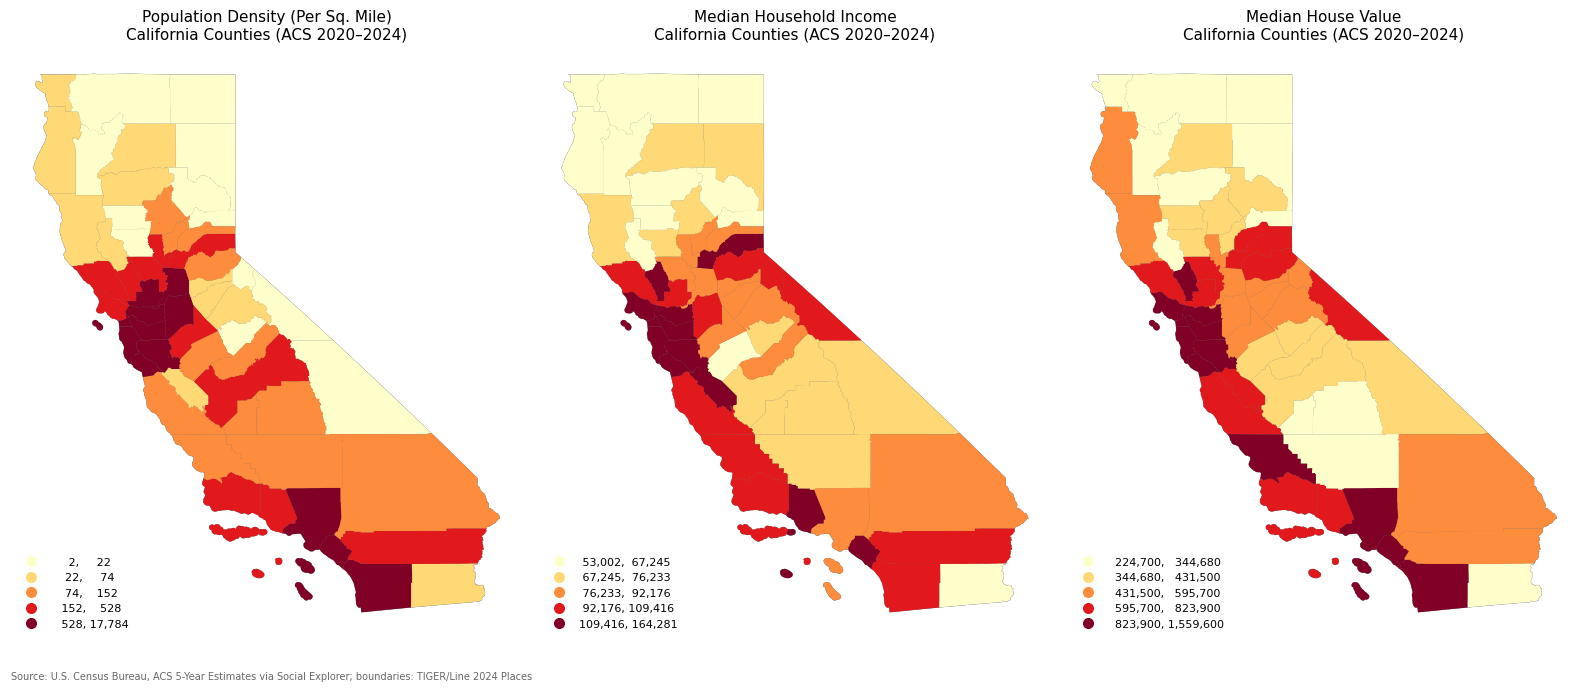

In [252]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

maps = [
    ('POPDEN', 'Population Density (Per Sq. Mile)'),
    ('Median Household Income', 'Median Household Income'),
    ("Median House Value", "Median House Value")
]

for ax, (col, title) in zip(axes, maps):
    counties.plot(ax = ax, color='#2a2a2e', edgecolor='#999999', linewidth=0.3)
    geo_census_house.plot(
        ax=ax,
        column=col, # Data to plot
        legend=True,
        cmap='YlOrRd', # color palette
        scheme='quantiles',
        k=5,
        linewidth=0.2,
        legend_kwds={'fmt': '{:,.0f}', 'loc': 'lower left',
                     'markerscale': 0.8, 'frameon': False, 'fontsize': 8}
    )
    ax.set_title(f'{title}\nCalifornia Counties (ACS 2020–2024)', fontsize=11)
    ax.set_axis_off()

fig.text(0.01, 0.02,
         'Source: U.S. Census Bureau, ACS 5-Year Estimates via Social Explorer; '
         'boundaries: TIGER/Line 2024 Places',
         fontsize=7, color='#666666')

fig.tight_layout()
plt.show()

It shows that California's population density, household income, and housing prices are highly clustered in the Bay Area and the Los Angeles-San Diego along the coast. The San Francisco region ranks at the highest level in all three indicators, while the Central Valley and the northern inland counties are consistently lower.

## Housing Price-to-Income Ratio

In [253]:
geo_census_house["val2Income ratio"] = geo_census_house["Median House Value"] / geo_census_house["Median Household Income"]
geo_census_house.head()

,GEOID,COUNTYNAME,geometry,TPOP,POPDEN,Median Household Income,Median House Value,val2Income ratio
0,6091,Sierra County,"POLYGON ((-13431319.751 4821511.426, -13431312...",2746,2.880918,63355,331900,5.238734
1,6067,Sacramento County,"POLYGON ((-13490651.476 4680831.603, -13490511...",1594006,1651.341016,92175,534200,5.795498
2,6083,Santa Barbara County,"MULTIPOLYGON (((-13440081.316 4150394.004, -13...",443701,162.293544,98161,790700,8.055134
3,6009,Calaveras County,"POLYGON ((-13428575.483 4627725.227, -13428534...",46248,45.340457,78647,457200,5.813318
4,6111,Ventura County,"MULTIPOLYGON (((-13283668.94 4059436.934, -132...",837469,454.953448,109797,822700,7.492919


### Maps Price_to_Income Ratio

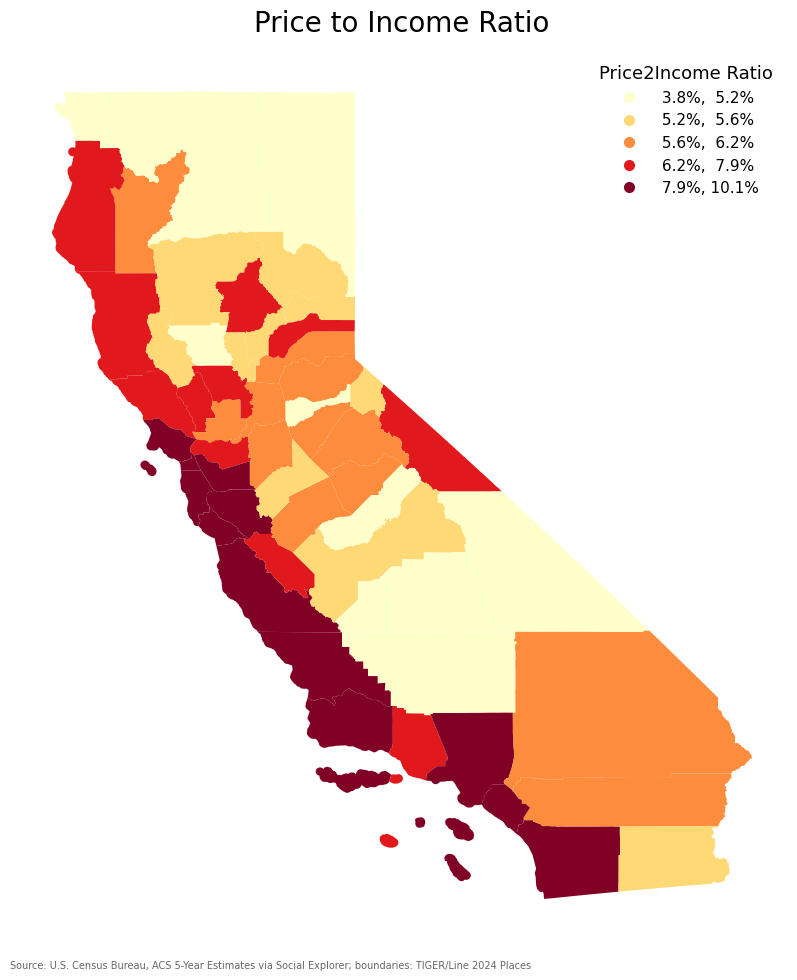

In [254]:
# Source: https://geopandas.org/en/stable/docs/user_guide/mapping.html

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

geo_census_house.plot(
    ax=ax,
    column="val2Income ratio", # Data to plot
    cmap='YlOrRd', # color palette
    legend=True,
    scheme='quantiles', # k = 5, Number of classes defalut is 5
    linewidth=0.5,
    legend_kwds={"title": "Price2Income Ratio", 'fmt': '{:.1f}%', 'loc': 'upper right',
                  'markerscale': 0.8, 'frameon': False, 'fontsize': 11, "title_fontsize": 13, 'edgecolor':"black"}
)


ax.set_title("Price to Income Ratio",
             fontsize=20, pad=14)


fig.text(0.01, 0.02,
         'Source: U.S. Census Bureau, ACS 5-Year Estimates via Social Explorer; '
         'boundaries: TIGER/Line 2024 Places',
         fontsize=7, color='#666666')

ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

It shows that California counties have substantial differences in their price-to-income ratios, ranging from about 3.8% to 10.1%. Counties with darker shading have higher ratio, indicating that housing is less affordable relative to local income compared with counties.

## California Unemployment Data
Source: Social explorer
American Community Survey 2020--2024 (5-Year-Estimates) https://www.socialexplorer.com/reports/socialexplorer/en/report/bac15980-b308-11f1-9512-c38da70940e6

#### Load the data

In [255]:
# Labor Force 16 Years and Over
unemployment = pd.read_csv("https://github.com/HowardChen0211/gisPy/raw/refs/heads/main/CA_UnemploymentRate.csv")
unemployment.head()

,FIPS,GeoLevel,NAME,Qualified Area Name,Area (Land),Area (Water),Civilian Population in Labor Force 16 Years and Over,Civilian Population in Labor Force 16 Years and Over: Employed,Civilian Population in Labor Force 16 Years and Over: Unemployed
0,Geo_FIPS,_geo_level_,Geo_NAME,Geo_qname,Geo_AREALAND,Geo_AREAWATER,SE_A17005_001,SE_A17005_002,SE_A17005_003
1,06001,SL050,"Alameda County, California","Alameda County, California",1910010500,216909647,908995,860129,48866
2,06003,SL050,"Alpine County, California","Alpine County, California",1912292607,12557304,837,800,37
3,06005,SL050,"Amador County, California","Amador County, California",1539967082,29437117,17257,16325,932
4,06007,SL050,"Butte County, California","Butte County, California",4238545149,105204062,100743,93228,7515


#### Clean the data

In [256]:
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 9 columns):
 #   Column                                                            Non-Null Count  Dtype 
---  ------                                                            --------------  ----- 
 0   FIPS                                                              59 non-null     object
 1   GeoLevel                                                          59 non-null     object
 2   NAME                                                              59 non-null     object
 3   Qualified Area Name                                               59 non-null     object
 4   Area (Land)                                                       59 non-null     object
 5   Area (Water)                                                      59 non-null     object
 6   Civilian Population in Labor Force 16 Years and Over              59 non-null     object
 7   Civilian Population in Labor Force 16 Years and

In [257]:
unemployment.isna().sum()

,0
FIPS,0
GeoLevel,0
NAME,0
Qualified Area Name,0
Area (Land),0
Area (Water),0
Civilian Population in Labor Force 16 Years and Over,0
Civilian Population in Labor Force 16 Years and Over: Employed,0
Civilian Population in Labor Force 16 Years and Over: Unemployed,0


In [258]:
unemployment.duplicated().sum()

np.int64(0)

In [259]:
# Choose the columns I want
unemployment = unemployment[["FIPS",
                             "NAME",
                             'Civilian Population in Labor Force 16 Years and Over',
                             'Civilian Population in Labor Force 16 Years and Over: Employed',
                             'Civilian Population in Labor Force 16 Years and Over: Unemployed']].iloc[1:, :]

In [260]:
# Rename the columns
unemployment.rename(columns={"NAME":"County",
                             "Civilian Population in Labor Force 16 Years and Over": "Labor Force",
                             "Civilian Population in Labor Force 16 Years and Over: Employed": "Employed",
                             'Civilian Population in Labor Force 16 Years and Over: Unemployed':"Unemployed"}, inplace=True)

In [261]:
# get rid of ' County, California'
unemployment["County"] = unemployment["County"].str.replace(" County, California", "")
unemployment.head()

,FIPS,County,Labor Force,Employed,Unemployed
1,06001,Alameda,908995,860129,48866
2,06003,Alpine,837,800,37
3,06005,Amador,17257,16325,932
4,06007,Butte,100743,93228,7515
5,06009,Calaveras,19422,18545,877


In [262]:
# Convert the data type
unemployment['Labor Force'] = unemployment['Labor Force'].astype(int)
unemployment['Employed'] = unemployment['Employed'].astype(int)
unemployment['Unemployed'] = unemployment['Unemployed'].astype(int)
unemployment['Rate'] = unemployment['Unemployed'] / unemployment['Labor Force'] * 100

unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 1 to 58
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FIPS         58 non-null     object 
 1   County       58 non-null     object 
 2   Labor Force  58 non-null     int64  
 3   Employed     58 non-null     int64  
 4   Unemployed   58 non-null     int64  
 5   Rate         58 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 2.8+ KB


In [263]:
unemployment.head()

,FIPS,County,Labor Force,Employed,Unemployed,Rate
1,06001,Alameda,908995,860129,48866,5.375827
2,06003,Alpine,837,800,37,4.420550
3,06005,Amador,17257,16325,932,5.400707
4,06007,Butte,100743,93228,7515,7.459575
5,06009,Calaveras,19422,18545,877,4.515498


In [264]:
counties.head()

,GEOID,NAME,NAMELSAD,ALAND,AWATER,geometry
0,6091,Sierra,Sierra County,2.468695e+09,2.329911e+07,"POLYGON ((-13431319.751 4821511.426, -13431312..."
1,6067,Sacramento,Sacramento County,2.499984e+09,7.542543e+07,"POLYGON ((-13490651.476 4680831.603, -13490511..."
2,6083,Santa Barbara,Santa Barbara County,7.084063e+09,2.729752e+09,"MULTIPOLYGON (((-13440081.316 4150394.004, -13..."
3,6009,Calaveras,Calaveras County,2.641785e+09,4.384187e+07,"POLYGON ((-13428575.483 4627725.227, -13428534..."
4,6111,Ventura,Ventura County,4.771988e+09,9.473454e+08,"MULTIPOLYGON (((-13283668.94 4059436.934, -132..."


In [265]:
# check = pd.merge(counties, unemployment, left_on="NAME", right_on="County", how="outer", indicator=True)
# check.query("_merge == 'left_only'")

In [266]:
# Merge Counties with unemployment data (I've already check the outter join, it's good.)
gdf = pd.merge(counties, unemployment, left_on="NAME", right_on="County", how="inner")
gdf.head()

,GEOID,NAME,NAMELSAD,ALAND,AWATER,geometry,FIPS,County,Labor Force,Employed,Unemployed,Rate
0,6091,Sierra,Sierra County,2.468695e+09,2.329911e+07,"POLYGON ((-13431319.751 4821511.426, -13431312...",06091,Sierra,1243,1086,157,12.630732
1,6067,Sacramento,Sacramento County,2.499984e+09,7.542543e+07,"POLYGON ((-13490651.476 4680831.603, -13490511...",06067,Sacramento,805946,751850,54096,6.712112
2,6083,Santa Barbara,Santa Barbara County,7.084063e+09,2.729752e+09,"MULTIPOLYGON (((-13440081.316 4150394.004, -13...",06083,Santa Barbara,219992,205874,14118,6.417506
3,6009,Calaveras,Calaveras County,2.641785e+09,4.384187e+07,"POLYGON ((-13428575.483 4627725.227, -13428534...",06009,Calaveras,19422,18545,877,4.515498
4,6111,Ventura,Ventura County,4.771988e+09,9.473454e+08,"MULTIPOLYGON (((-13283668.94 4059436.934, -132...",06111,Ventura,431630,406900,24730,5.729444


In [267]:
# Double check the missing values
gdf.isna().sum()

,0
GEOID,0
NAME,0
NAMELSAD,0
ALAND,0
AWATER,0
geometry,0
FIPS,0
County,0
Labor Force,0
Employed,0


### Maps County Unemployment Rates

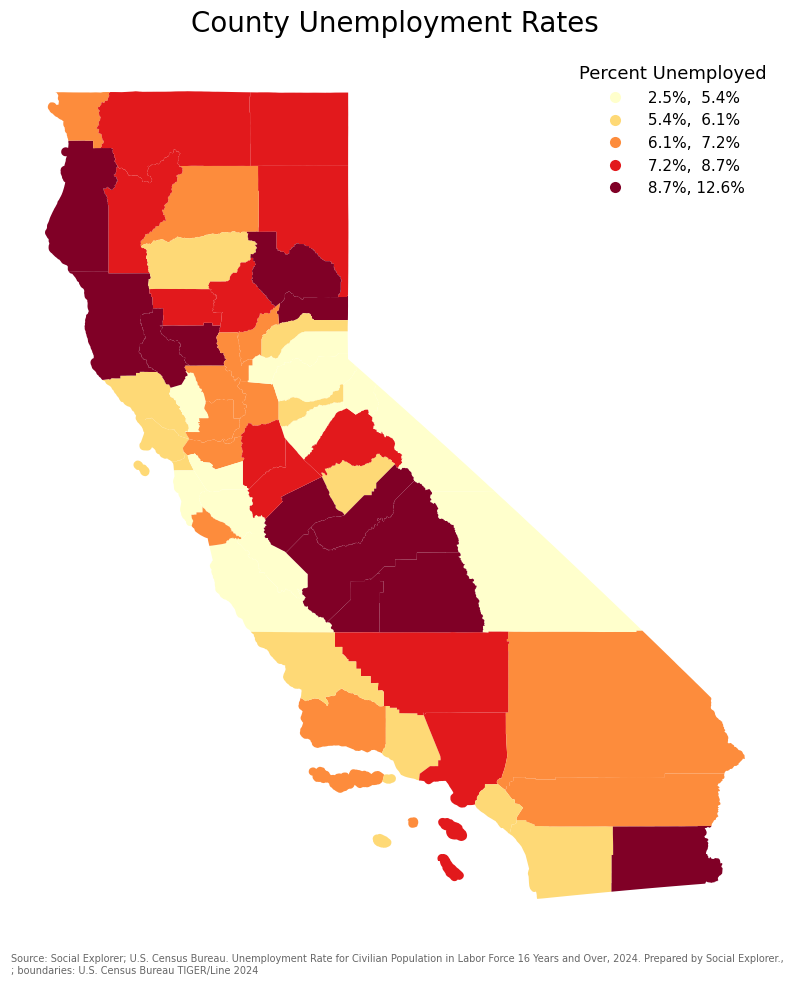

In [268]:
# Source: https://geopandas.org/en/stable/docs/user_guide/mapping.html

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

gdf.plot(
    ax=ax,
    column="Rate", # Data to plot
    cmap='YlOrRd', # color palette
    legend=True,
    scheme='quantiles', # k = 5, Number of classes defalut is 5
    linewidth=0.5,
    legend_kwds={"title": "Percent Unemployed", 'fmt': '{:.1f}%', 'loc': 'upper right',
                  'markerscale': 0.8, 'frameon': False, 'fontsize': 11, "title_fontsize": 13}
)


ax.set_title("County Unemployment Rates",
             fontsize=20, pad=14)


fig.text(0.02, 0.015,
         "Source: Social Explorer; U.S. Census Bureau. Unemployment Rate for Civilian Population in Labor Force 16 Years and Over, 2024. Prepared by Social Explorer., "
         "\n; boundaries: U.S. Census Bureau TIGER/Line 2024",
         fontsize=7, color="#666666")

ax.set_axis_off()
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

## Reference
1. Designated Cities: https://en.wikipedia.org/wiki/List_of_census-designated_places_in_California

2. Municipalities: https://en.wikipedia.org/wiki/List_of_municipalities_in_California

3. Counties: https://en.wikipedia.org/wiki/List_of_counties_in_California

4. Social Explorer; U.S. Census Bureau. Total Population, 2024. Prepared by Social Explorer. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A00001

5. Social Explorer; U.S. Census Bureau. Population Density (Per Sq. Mile), 2024. Prepared by Social Explorer. https://www.socialexplorer.com/data/ACS2024_5yr/metadata?ds=SE&table=A00002


